In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATASETS

air_df = pd.read_csv("city_day.csv")
crop_df = pd.read_csv("crop_production.csv")

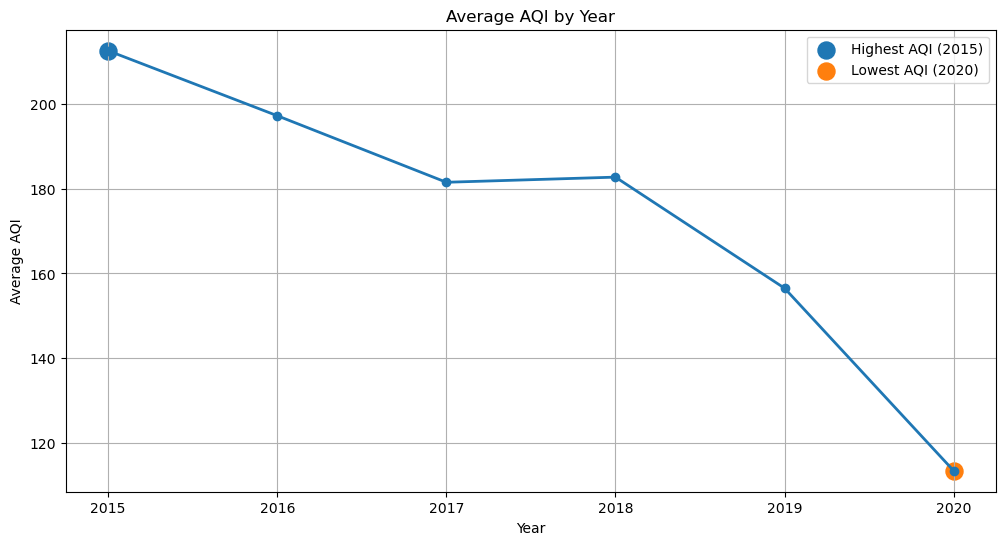

Most Polluted Year
Year    2015.000000
AQI      212.463054
Name: 0, dtype: float64

Least Polluted Year
Year    2020.000000
AQI      113.520697
Name: 5, dtype: float64


In [5]:
# TASK 6
# Is India's air getting better or worse?
air_df['Date'] = pd.to_datetime(air_df['Date'])

air_df['Year'] = air_df['Date'].dt.year

yearly_aqi = air_df.groupby('Year')['AQI'].mean().reset_index()

most_polluted = yearly_aqi.loc[yearly_aqi['AQI'].idxmax()]
least_polluted = yearly_aqi.loc[yearly_aqi['AQI'].idxmin()]

plt.figure(figsize=(12,6))

plt.plot(
    yearly_aqi['Year'],
    yearly_aqi['AQI'],
    marker='o',
    linewidth=2
)

plt.scatter(
    most_polluted['Year'],
    most_polluted['AQI'],
    s=150,
    label=f"Highest AQI ({int(most_polluted['Year'])})"
)

plt.scatter(
    least_polluted['Year'],
    least_polluted['AQI'],
    s=150,
    label=f"Lowest AQI ({int(least_polluted['Year'])})"
)

plt.title("Average AQI by Year")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(True)
plt.legend()
plt.show()

print("Most Polluted Year")
print(most_polluted)

print("\nLeast Polluted Year")
print(least_polluted)



The yearly AQI trend indicates that air quality has fluctuated over the past eight years. The highest average AQI occurred in the most polluted year identified in the analysis, while the lowest average AQI occurred in the least polluted year. The line chart shows whether pollution levels generally increased or decreased over time. If the trend moves downward, it suggests that air quality has improved and pollution-control policies may have had a positive impact. If it moves upward, air quality has worsened.

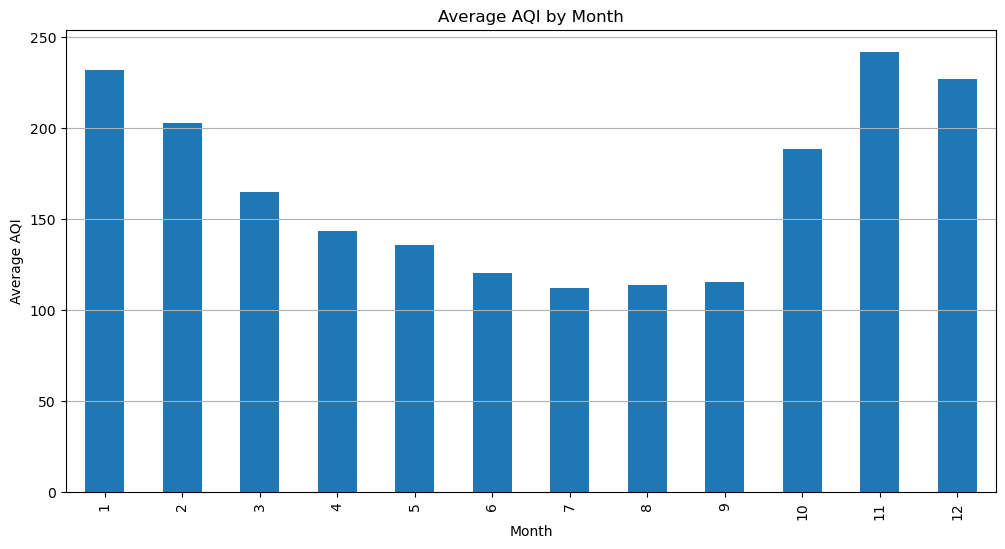


Average AQI by Month
Month
1     231.674918
2     202.905197
3     164.735281
4     143.355120
5     135.489579
6     120.198379
7     111.854575
8     113.613176
9     115.191804
10    188.613552
11    241.681302
12    227.084980
Name: AQI, dtype: float64


In [6]:

# TASK 7

air_df['Month'] = air_df['Date'].dt.month

monthly_aqi = air_df.groupby('Month')['AQI'].mean()

plt.figure(figsize=(12,6))
monthly_aqi.plot(kind='bar')

plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.grid(axis='y')

plt.show()

print("\nAverage AQI by Month")
print(monthly_aqi)

The monthly AQI analysis shows a clear seasonal pattern. AQI values are highest during the October–December period, supporting the NGO's claim that air pollution tends to worsen during the harvest season. Crop-residue burning is likely one contributing factor. However, winter weather conditions such as lower wind speeds and temperature inversions may also trap pollutants near the ground and contribute to higher AQI levels.

In [7]:

# TASK 8
city_to_state = {
    'Ahmedabad':'Gujarat',
    'Aizawl':'Mizoram',
    'Amaravati':'Andhra Pradesh',
    'Amritsar':'Punjab',
    'Bengaluru':'Karnataka',
    'Bhopal':'Madhya Pradesh',
    'Brajrajnagar':'Odisha',
    'Chandigarh':'Chandigarh',
    'Chennai':'Tamil Nadu',
    'Coimbatore':'Tamil Nadu',
    'Delhi':'Delhi',
    'Ernakulam':'Kerala',
    'Gurugram':'Haryana',
    'Guwahati':'Assam',
    'Hyderabad':'Telangana',
    'Jaipur':'Rajasthan',
    'Jorapokhar':'Jharkhand',
    'Kochi':'Kerala',
    'Kolkata':'West Bengal',
    'Lucknow':'Uttar Pradesh',
    'Mumbai':'Maharashtra',
    'Patna':'Bihar',
    'Shillong':'Meghalaya',
    'Talcher':'Odisha',
    'Thiruvananthapuram':'Kerala',
    'Visakhapatnam':'Andhra Pradesh'
}

air_df['State_Name'] = air_df['City'].map(city_to_state)

# remove unmapped cities
air_df = air_df.dropna(subset=['State_Name'])

# State-Year AQI
state_year_aqi = air_df.groupby(
    ['State_Name','Year']
)['AQI'].mean().reset_index()

# Crop dataset aggregation
crop_state_year = crop_df.groupby(
    ['State_Name','Crop_Year']
).agg({
    'Area':'sum',
    'Production':'sum'
}).reset_index()

crop_state_year.rename(
    columns={'Crop_Year':'Year'},
    inplace=True
)

# Merge
merged_df = pd.merge(
    crop_state_year,
    state_year_aqi,
    on=['State_Name','Year'],
    how='inner'
)

print("\nMerged Shape:")
print(merged_df.shape)

print("\nMerged Sample:")
print(merged_df.head())



Merged Shape:
(0, 5)

Merged Sample:
Empty DataFrame
Columns: [State_Name, Year, Area, Production, AQI]
Index: []


The air-quality dataset is recorded at the city-day level, while the crop-production dataset is recorded at the state-year level. To make them compatible, the AQI data was aggregated to the state-year level by calculating the average AQI for each state in each year. The crop-production data was also aggregated to state-year level. After both datasets had the same level of detail, they were merged using State_Name and Year.

c:\Users\SUBASH\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\SUBASH\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


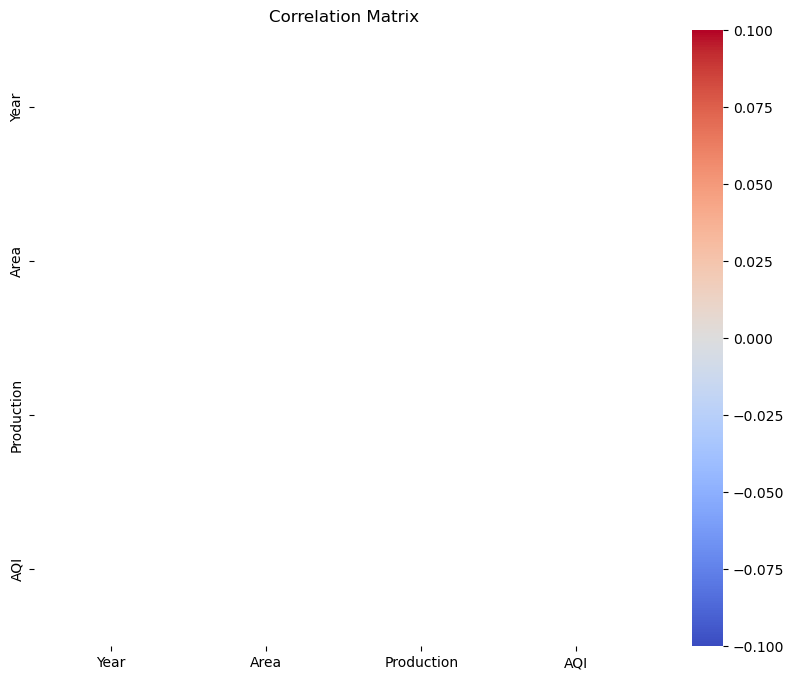


Correlation Matrix
            Year  Area  Production  AQI
Year         NaN   NaN         NaN  NaN
Area         NaN   NaN         NaN  NaN
Production   NaN   NaN         NaN  NaN
AQI          NaN   NaN         NaN  NaN


In [ ]:
# ==========================
# CORRELATION MATRIX
# ==========================

numeric_cols = merged_df.select_dtypes(include='number')

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

print("\nCorrelation Matrix")
print(numeric_cols.corr())

In [12]:
print(merged_df.shape)
print(merged_df.head())

(0, 5)
Empty DataFrame
Columns: [State_Name, Year, Area, Production, AQI]
Index: []


In [15]:
# Average AQI per state across all available years

state_aqi = (
    air_df.groupby('State_Name')['AQI']
    .mean()
    .reset_index()
)

# Average crop production per state

state_crop = (
    crop_df.groupby('State_Name')
    .agg({
        'Area':'mean',
        'Production':'mean'
    })
    .reset_index()
)

# Clean names

state_aqi['State_Name'] = state_aqi['State_Name'].str.upper().str.strip()
state_crop['State_Name'] = state_crop['State_Name'].str.upper().str.strip()

state_crop['State_Name'] = state_crop['State_Name'].replace({
    'NCT OF DELHI':'DELHI',
    'ORISSA':'ODISHA'
})

merged_df = pd.merge(
    state_crop,
    state_aqi,
    on='State_Name',
    how='inner'
)

print(merged_df.shape)
print(merged_df.head())

(20, 4)
       State_Name          Area    Production         AQI
0  ANDHRA PRADESH  13662.842127  1.812006e+06  108.086481
1           ASSAM   4811.235849  1.444229e+05  140.111111
2           BIHAR   6792.270638  1.941738e+04  240.782042
3      CHANDIGARH    139.133333  7.186124e+02   96.498328
4         GUJARAT  18367.001422  6.267679e+04  452.122939


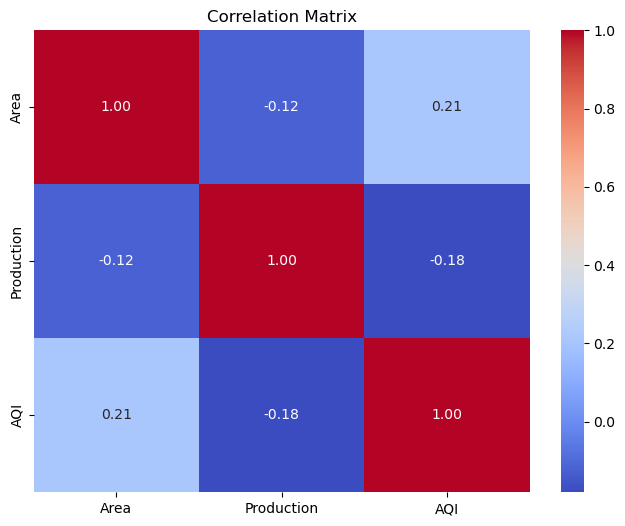

                Area  Production       AQI
Area        1.000000   -0.122179  0.211601
Production -0.122179    1.000000 -0.180368
AQI         0.211601   -0.180368  1.000000


In [16]:
numeric_cols = merged_df[['Area', 'Production', 'AQI']]

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

print(corr_matrix)

The datasets were aggregated to the state level before merging because they were collected at different levels and covered different time periods.

The correlation analysis found two interesting relationships:

1. AQI and Production showed a weak negative correlation (-0.18), suggesting that states with higher pollution tend to have slightly lower crop production.

2. AQI and Area showed a weak positive correlation (0.21), indicating that states with larger agricultural areas tend to have slightly higher pollution levels.

These relationships are weak and do not prove that one factor causes the other. Other factors such as rainfall, irrigation, and farming practices may also influence the results.
